# Structural network mapping

In this tutorial, you will explore the structural network mapping functionalities of Lacuna using the CLI.

**What you'll learn**:

- Fetch a structural connectome
- Obtain voxel-level disconnectivity maps
- Compute a disconnectivity matrix
- Compute ROI-wise disconnection values

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/m-petersen/lacuna/blob/main/docs/tutorials/structural-network-mapping.ipynb)


In [1]:
# --- Conda Setup For Google Colab ---
# Colab does not ship with conda, but MRtrix3 requires it.
# We use condacolab to replace Colab's Python with a Mambaforge-based environment.
#
# IMPORTANT: Running this cell will RESTART the kernel automatically.
# After the restart, SKIP this cell and continue from the next cell onward.
# (Do NOT re-run this cell after the restart.)

import os

if os.environ.get("CONDA_PREFIX") is None:
    # Conda not yet installed — install condacolab and trigger restart
    !pip install -q condacolab==0.1.9
    import condacolab
    condacolab.install()  # This restarts the kernel

In [2]:
# Run this after the kernel restart. 
# Also start here when the kernel crashes for some other reason.


import sys

# Check if the notebook is running in Google Colab
if 'google.colab' in sys.modules:
    # Verify condacolab is active and append conda paths to the active Colab kernel's paths
    import condacolab
    import subprocess

    condacolab.check()

    conda_paths = subprocess.check_output(
        "python -c 'import sys; print(\"\\n\".join(sys.path))'", 
        shell=True, text=True
    ).split('\n')

    for path in conda_paths:
        if path and path not in sys.path:
            sys.path.append(path)
    
    print("Colab environment detected: condacolab initialized.")

## Setup

In [3]:
# Install Lacuna from GitHub
!pip install git+https://github.com/m-petersen/lacuna

# Install MRtrix3 via conda
!conda install -c conda-forge -c MRtrix3 mrtrix3 libstdcxx-ng -y

# Install FURY for visualization
!pip install fury

# Get tutorial data
!lacuna tutorial /tmp/tutorial_bids

  Cloning https://github.com/m-petersen/lacuna to /tmp/pip-req-build-swthdl6e
  Running command git clone --filter=blob:none --quiet https://github.com/m-petersen/lacuna /tmp/pip-req-build-swthdl6e
  Resolved https://github.com/m-petersen/lacuna to commit 010dcb2e19f42920af3c9d0a8a746509d1ceeb90
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for lacuna: filename=lacuna-0.0.1.dev351-py3-none-any.whl size=3976136 sha256=7ed60c17d62d5b3f6b9196fadbd79e0c23b39fee9e22639512f8c8f996709e05
  Stored in directory: /tmp/pip-ephem-wheel-cache-t689pem9/wheels/f2/47/73/b700514669e601f0dde178de2d7016138fa840bd514ac68002
Successfully built lacuna
  Attempting uninstall: lacuna
    Found existing installation: lacuna 0.0.1.dev350
    Uninstalling lacuna-0.0.1.dev350:
      Successfully uninstalled lacuna-0.0.1.dev350
Solving environment: / 
  - mrtrix3/linux-64::mrtrix3-3.0.8-h07fc403_0
  - MRtrix3/l

Check whether mrtrix3 is properly installed as it is required for the analysis

In [4]:
!mrinfo --version

== mrinfo 3.0.8 ==
64 bit release version, built Oct 21 2025, using Eigen 3.4.0
Author(s): J-Donald Tournier (jdtournier@gmail.com) and Robert E. Smith (robert.smith@florey.edu.au)
Copyright (c) 2008-2025 the MRtrix3 contributors.

This Source Code Form is subject to the terms of the Mozilla Public
License, v. 2.0. If a copy of the MPL was not distributed with this
file, You can obtain one at http://mozilla.org/MPL/2.0/.

Covered Software is provided under this License on an "as is"
basis, without warranty of any kind, either expressed, implied, or
statutory, including, without limitation, warranties that the
Covered Software is free of defects, merchantable, fit for a
particular purpose or non-infringing.
See the Mozilla Public License v. 2.0 for more details.

For more details, see http://www.mrtrix.org/.



## Fetch structural connectome

Structural lesion network mapping requires a structural connectome in form of a normative tractogram, i.e., white matter fiber bundle reconstruction derived from diffusion-weighted MRI.

If possible, we recommend using [dTOR985](https://springernature.figshare.com/articles/dataset/dTOR-985_structural_connectome_full_tractogram_trk_file/25209947) instead as it has higher coverage. With ~12 million streamlines this connectome is a bit more computationally demanding. The fetching process involves a conversion to `.tck` format which needs 32gb RAM. To download it you need a Figshare personal token. You can obtain this token by logging into [figshare.com](https://figshare.com), navigating to Account, then Integrations, and finally selecting Personal Tokens.

In this tutorial, we use the [HCP1065](https://brain.labsolver.org/hcp_trk_atlas.html) tractogram which is a combination of individual tract bundles.

In [5]:
!lacuna fetch hcp1065 \
    --output-dir /tmp/hcp1065_data

Fetching HCP1065 structural tractogram...
  Output: /tmp/hcp1065_data
  Keep original: True


✓ HCP1065 fetch complete!
  Files: 1
  Duration: 0.0s
  Output: /tmp/hcp1065_data


Plot the tractogram and the lesion (in white) with [FURY](https://fury.gl/latest/index.html).

/home/marvin/miniconda3/envs/lacuna/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: UserWarning: We'll no longer accept the way you call the record function in future versions of FURY.

Here's how to call the Function record: record(scene='value', cam_pos='value', cam_focal='value', cam_view='value', out_path='value', path_numbering='value', n_frames='value', az_ang='value', magnification='value', size='value', reset_camera='value', screen_clip='value', stereo='value', verbose='value')

  exec(code_obj, self.user_global_ns, self.user_ns)


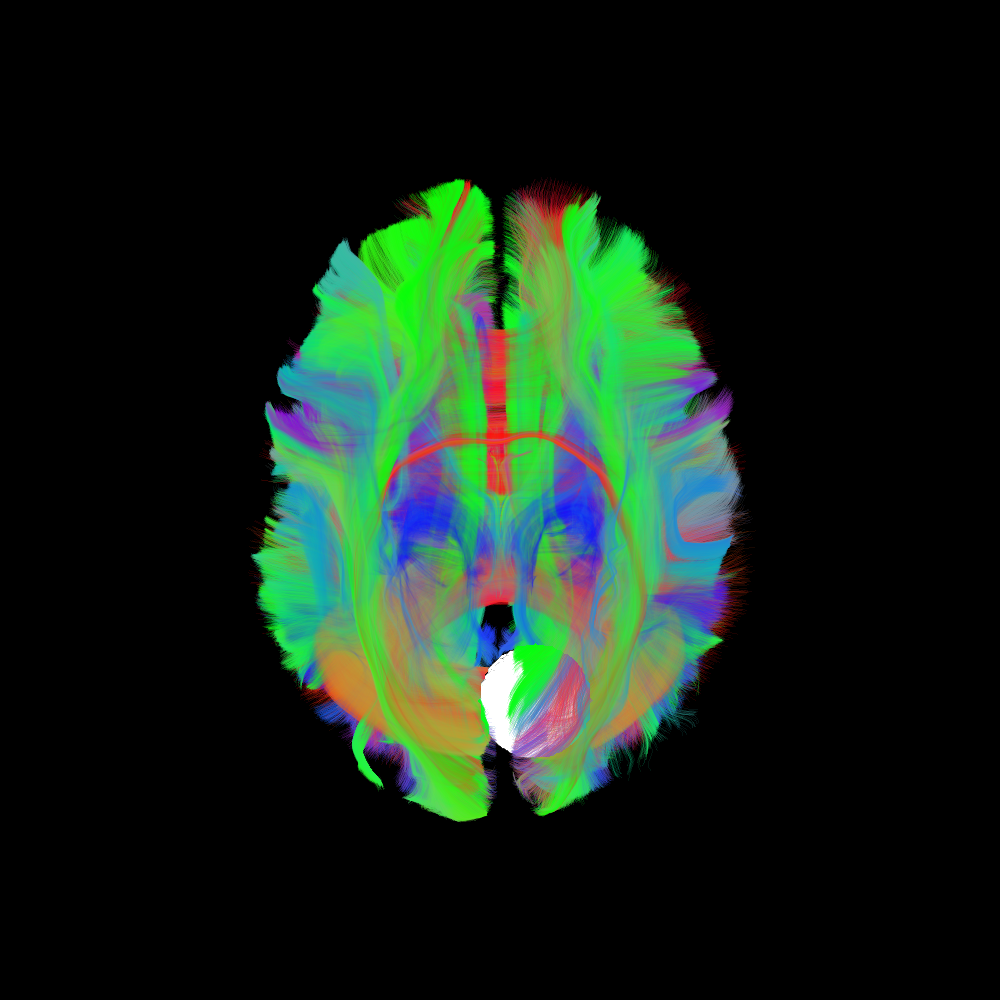

In [6]:
import nibabel as nib
from fury import actor, window, colormap
from IPython.display import Image, display

streamlines = nib.streamlines.load("/tmp/hcp1065_data/hcp1065.tck").streamlines
mask_img = nib.load("/tmp/tutorial_bids/sub-01/ses-01/anat/sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_mask.nii.gz")


mask_actor = actor.contour_from_roi(mask_img.get_fdata(), 
                                    affine=mask_img.affine, 
                                    color=(255, 255, 255),
                                    opacity=1)

colors = colormap.line_colors(streamlines)

tract_actor = actor.line(streamlines, 
                         colors=colors,
                         opacity=0.1)


scene = window.Scene()
scene.add(mask_actor)
scene.add(tract_actor)

window.record(scene, out_path='/tmp/tractogram.png', size=(1000, 1000))
display(Image('/tmp/tractogram.png'))

## Analysis
By filtering the normative tractogram based on the mask image, structural lesion network mapping identifies white matter fiber bundles connected to a specific lesion. By that, we can infer which pathways have been disconnected or disrupted.

What the structural network mapping implementation internally does: 
1. Ensure spatial alignment
2. Compute the voxel-level tract density image (TDI) of full tractogram (amount of streamlines per voxel)
3. Filter the normative tractogram by the lesion mask
4. Compute the TDI of the lesion filtered tractogram and divide the lesion TDI by the original TDI to obtain a disconnection map (% of streamlines connected to the lesion).



Now run the analysis.

In [7]:
!lacuna run snm \
    /tmp/tutorial_bids/ \
    /tmp/outputs_snm_run1/ \
    --connectome-path /tmp/hcp1065_data/hcp1065.tck \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym

The standard run as shown above produces voxel-level disconnectivity maps.

In [60]:
!ls /tmp/outputs_snm_run1/sub-01/ses-01/anat/

sub-01_ses-01_desc-provenance.json
sub-01_ses-01_label-acuteinfarct_summarystatistics_stats.json
sub-01_ses-01_space-MNI152NLin2009cAsym_label-acuteinfarct_mask.nii.gz
sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_desc-snm_disconnectionmap.json
sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_desc-snm_disconnectionmap.nii.gz


Visualize the output.

/tmp/ipykernel_214916/1029981045.py:6: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(disconnection_img,


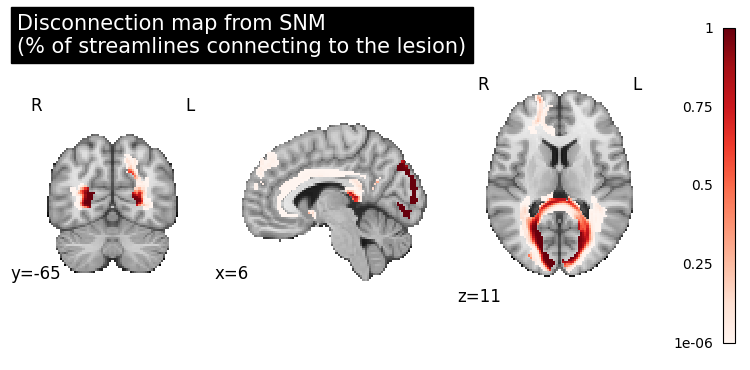

In [46]:
from nilearn import plotting

disconnection_path = '/tmp/outputs_snm/sub-01/ses-01/anat/sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_desc-snm_disconnectionmap.nii.gz'
disconnection_img = nib.load(disconnection_path)

plotting.plot_stat_map(disconnection_img, 
                       radiological=True, 
                       title="Disconnection map from SNM \n(% of streamlines connecting to the lesion)", 
                       draw_cross=False, 
                       colorbar=True,
                       dim=-0.2,
                       cmap='Reds')

## Obtain ROI-level disconnectivity and disconnectivity matrix

Beyond voxel-level maps, Lacuna covers two further formats of disconnectivity information: region of interest-level disconnectivity scores and a disconnectivity matrix.

These require the `--compute-roi-disconnection` flag as well as definition of a parcellation atlas via `--parcel-atlas`.

In [17]:
!lacuna run snm \
    /tmp/tutorial_bids/ \
    /tmp/outputs_snm_run2/ \
    --connectome-path /tmp/hcp1065_data/hcp1065.tck \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym \
    --compute-disconnectivity-matrix \
    --compute-roi-disconnection \
    --parcel-atlas Schaefer2018_400Parcels7Networks \
    --verbose


usage: lacuna [-h] [--version] <command> ...
lacuna: error: unrecognized arguments: --compute-disconnectivity-matrix


In [ ]:
!ls /tmp/outputs_snm/sub-01/ses-01/anat/*matrix*

In [39]:
!lacuna run snm --help

usage: lacuna run snm [-h] [--participant-label LABEL [LABEL ...]]
                      [--session-id SESSION [SESSION ...]] [--pattern GLOB]
                      [--mask-space SPACE] [--nprocs N] [--batch-size N]
                      [-w PATH] [--overwrite] [--keep-intermediate] [-v]
                      --connectome-path PATH [--parcel-atlas NAME]
                      [--compute-roi-disconnection] [--output-resolution MM]
                      [--no-cache-tdi] [--no-return-input-space]
                      [--show-mrtrix-output]
                      bids_dir output_dir

Structural Network Mapping Analysis

Computes white matter disconnection using tractography.
Generates disconnection maps showing regions affected by
streamline interruption through lesioned tissue.

Requires MRtrix3 to be installed and in PATH.

Download a tractogram with 'lacuna fetch dtor985' first.

Examples:
  lacuna run snm /bids /output --connectome-path ~/.cache/lacuna/dtor985/tractogram.tck
  lacuna ru

Again, we look at the outputs.

In [37]:
!ls /tmp/outputs_snm/sub-01/ses-01/anat

sub-01_ses-01_desc-provenance.json
sub-01_ses-01_label-acuteinfarct_summarystatistics_stats.json
sub-01_ses-01_space-MNI152NLin2009cAsym_label-acuteinfarct_mask.nii.gz
sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_desc-snm_disconnectionmap.json
sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_desc-snm_disconnectionmap.nii.gz


/tmp/ipykernel_231747/2988687602.py:4: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(disconnection_img,


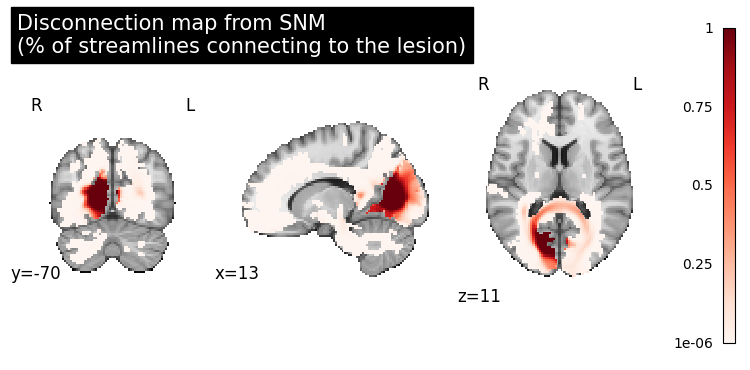

In [38]:
disconnection_path = '/tmp/outputs_snm/sub-01/ses-01/anat/sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_desc-snm_disconnectionmap.nii.gz'
disconnection_img = nib.load(disconnection_path)

plotting.plot_stat_map(disconnection_img, 
                       radiological=True, 
                       title="Disconnection map from SNM \n(% of streamlines connecting to the lesion)", 
                       draw_cross=False, 
                       colorbar=True,
                       dim=-0.2,
                       cmap='Reds')